# 4. Analyse RFM

## 4.1 Définition de la méthode RFM (développée)

La méthode RFM (Recency, Frequency, Monetary) est une technique utilisée pour analyser le comportement des clients à partir de leurs transactions passées.  
Elle permet d’identifier les clients les plus rentables, les plus fidèles ou au contraire ceux qui risquent d’être perdus.

### 1️⃣ Recency (R)

→ Mesure le temps écoulé depuis la dernière commande du client.  
Plus la valeur est basse, plus le client est récent et actif.

**Interprétation :**

- R faible = client récemment actif → important à fidéliser.  
- R élevé = client inactif depuis longtemps → risque de churn.

### 2️⃣ Frequency (F)

→ Indique le nombre total de commandes effectuées par le client.  
Plus la fréquence est élevée, plus le client est fidèle.

**Interprétation :**

- F élevé = client fidèle, relation forte.  
- F faible = client occasionnel.

### 3️⃣ Monetary (M)

→ Représente le montant total dépensé par le client.

**Interprétation :**

- M élevé = clients très rentables.  
- M faible = clients qui dépensent peu.

---

### Pourquoi utiliser RFM ?

- Identifier les meilleurs clients  
- Prioriser les actions marketing  
- Adapter les promotions selon les profils  
- Prévoir les risques de départ  
- Améliorer la stratégie de rétention




In [75]:
data.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4,Phone,3,6,Debit Card,Female,3,3,Laptop & Accessory,2,Single,9,1,11,1.0,1,5,159.93
1,50002,1,9,Phone,1,8,UPI,Male,3,4,Mobile,3,Single,7,1,15,0.0,1,3,120.90
2,50003,1,9,Phone,1,30,Debit Card,Male,2,4,Mobile,3,Single,6,1,14,0.0,1,3,120.28
3,50004,1,0,Phone,3,15,Debit Card,Male,2,4,Laptop & Accessory,5,Single,8,0,23,0.0,1,3,134.07
4,50005,1,0,Phone,1,12,CC,Male,3,3,Mobile,5,Single,3,0,11,1.0,1,3,129.60


**2 . Construction du tableau RFM**

In [76]:
tableRFM= data[["CustomerID" ,"DaySinceLastOrder" ,"OrderCount" ,"CashbackAmount"]]
tableRFM.head()

,CustomerID,DaySinceLastOrder,OrderCount,CashbackAmount
0,50001,5,1,159.93
1,50002,3,1,120.90
2,50003,3,1,120.28
3,50004,3,1,134.07
4,50005,3,1,129.60


In [77]:


tableRFM= tableRFM.rename(columns={
    'DaySinceLastOrder' :'Recency',
    'OrderCount' :'Frequency',
    'CashbackAmount' :'Monetary'
})



In [78]:
tableRFM.head()

,CustomerID,Recency,Frequency,Monetary
0,50001,5,1,159.93
1,50002,3,1,120.90
2,50003,3,1,120.28
3,50004,3,1,134.07
4,50005,3,1,129.60


## 4.2 Construction du tableau RFM

Pour analyser, il faut d’abord créer une base RFM à partir des données de commandes.

### Étapes détaillées

1️⃣ **Choisir une date de référence**  

Il s’agit généralement de :  
- la date la plus récente du dataset, ou  
- la date d’analyse choisie par l’entreprise.

C’est sur cette date qu’on calcule le temps écoulé (Recency).

2️⃣ **Calculer les métriques RFM**

- 🟦 **Recency (R)**  
  Calcul du nombre de jours entre la date de référence et la dernière commande du client.  
  Idée : plus le client a commandé récemment, plus il est actif.

- 🟩 **Frequency (F)**  
  Comptage du nombre total d’achats effectués par le client.  
  Idée : les clients réguliers sont à fidéliser en priorité.

- 🟧 **Monetary (M)**  
  Somme du montant total dépensé par le client.  
  Idée : identifier les gros contributeurs au chiffre d’affaires.

3️⃣ **Analyse statistique des valeurs R, F et M**

Pour mieux comprendre les données, on réalise plusieurs analyses :

- **Distribution des valeurs R, F, M**  
  - Voir si les clients achètent souvent → distribution de F  
  - Voir si la majorité est inactive → distribution de R  
  - Voir si beaucoup dépensent peu → analyse de M

- **Boxplots**  
  → Indispensables pour repérer les outliers :  
  - Gros dépenseurs  
  - Clients très inactifs  
  - Acheteurs compulsifs (F très élevé)

- **Histogrammes + statistiques descriptives**  
  Méditer sur : moyenne, médiane, quartiles  
  Repérer les anomalies  
  Comprendre la concentration des clients dans chaque variable

Cette étape permet d’avoir une vision globale de la base client avant segmentation.

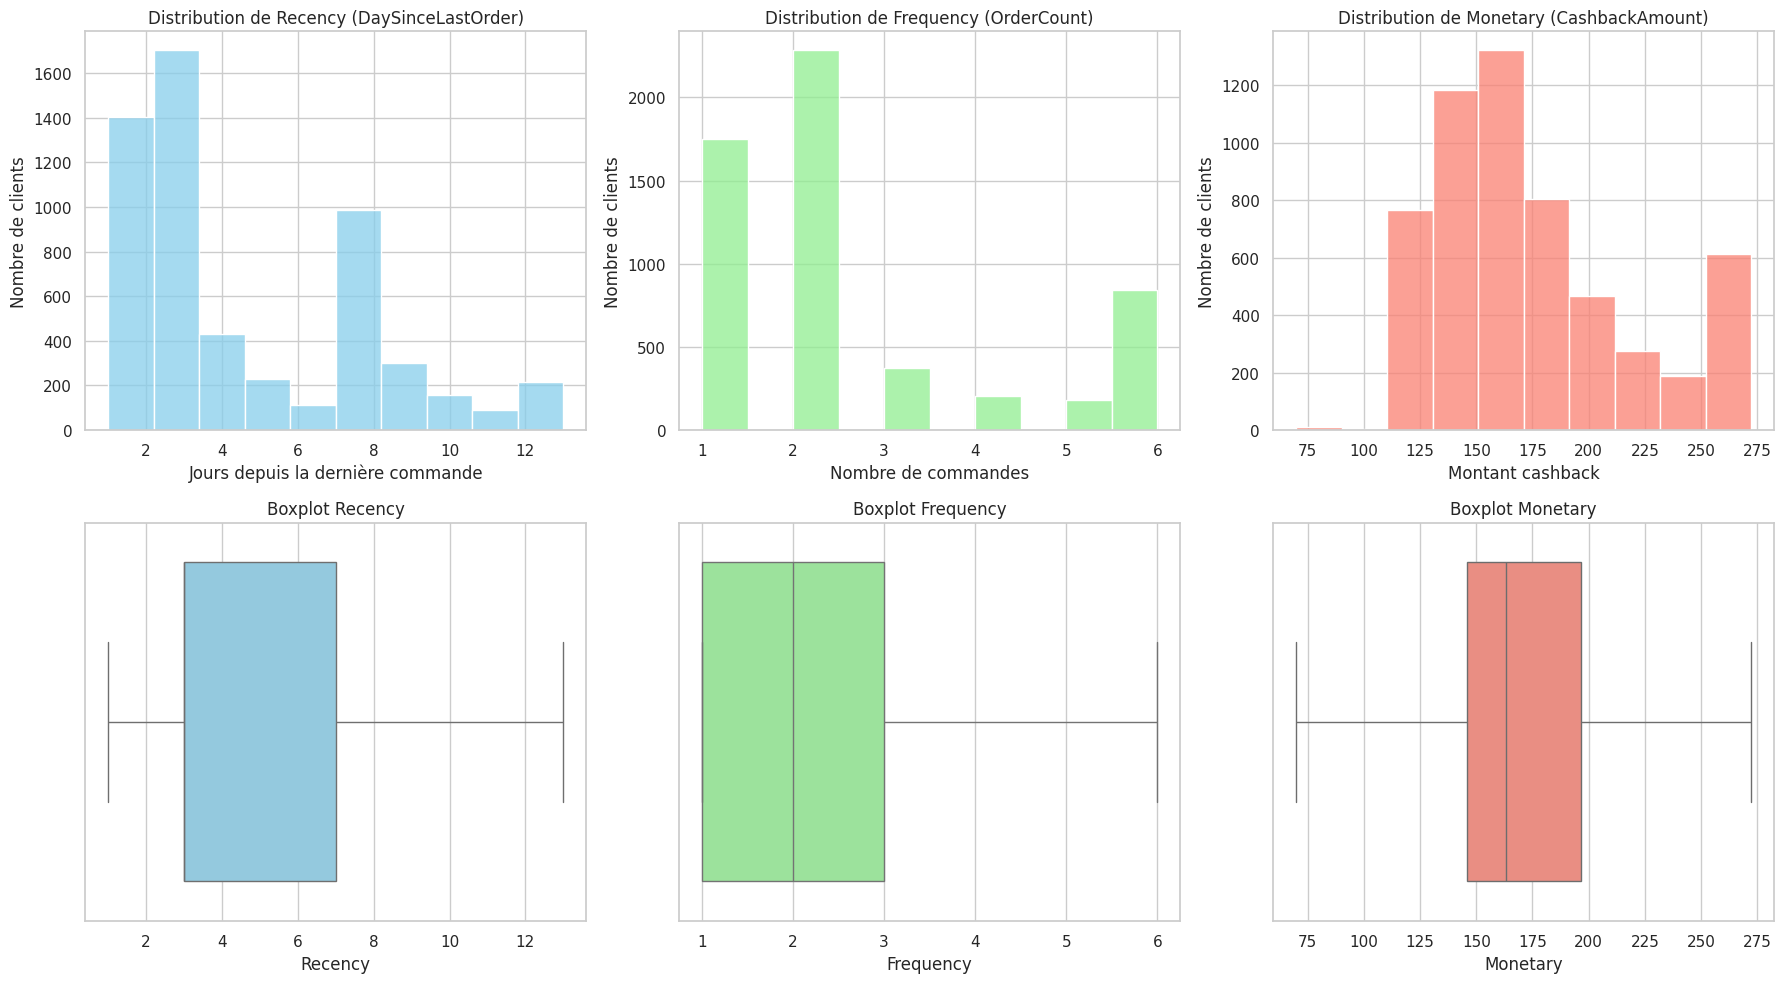

In [79]:
# Ton code pour créer les graphiques
sns.set(style="whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(tableRFM['Recency'], bins=10, kde=False, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution de Recency (DaySinceLastOrder)')
axes[0, 0].set_xlabel('Jours depuis la dernière commande')
axes[0, 0].set_ylabel('Nombre de clients')

sns.histplot(tableRFM['Frequency'], bins=10, kde=False, ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Distribution de Frequency (OrderCount)')
axes[0, 1].set_xlabel('Nombre de commandes')
axes[0, 1].set_ylabel('Nombre de clients')

sns.histplot(tableRFM['Monetary'], bins=10, kde=False, ax=axes[0, 2], color='salmon')
axes[0, 2].set_title('Distribution de Monetary (CashbackAmount)')
axes[0, 2].set_xlabel('Montant cashback')
axes[0, 2].set_ylabel('Nombre de clients')

sns.boxplot(x=tableRFM['Recency'], ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Boxplot Recency')

sns.boxplot(x=tableRFM['Frequency'], ax=axes[1, 1], color='lightgreen')
axes[1, 1].set_title('Boxplot Frequency')

sns.boxplot(x=tableRFM['Monetary'], ax=axes[1, 2], color='salmon')
axes[1, 2].set_title('Boxplot Monetary')

plt.tight_layout()

# Sauvegarder l'image dans le fichier 'rfm_plots.png'
plt.savefig('rfm_plots.png', dpi=300)  # dpi=300 pour bonne qualité

plt.show()


## 4.3 Classification RFM (Segmentation)

Pour transformer les valeurs RFM en catégories exploitables par le marketing, on attribue un score à chaque client.

### 1️⃣ Attribuer des scores R, F et M

On classe les clients en quantiles (ex. : 1 à 4 ou 1 à 5).

- Score R élevé = mauvais (car client ancien)  
- Score F élevé = bon  
- Score M élevé = bon

Au final, chaque client obtient un code RFM, par exemple :  
R=4, F=5, M=5 → 455

### 2️⃣ Créer les segments

À partir de ces scores, on classe les clients dans des segments marketing :

⭐ **Champions**  
Clients récents + fréquence élevée + dépenses élevées.  
→ Garder en priorité, offres VIP.

💛 **Loyal Customers**  
Achètent régulièrement.  
→ Fidélisation, programmes de points.

📈 **Potential Loyalists**  
Peuvent devenir loyaux avec une bonne stratégie.  
→ Ciblage, promotions personnalisées.

🆕 **New Customers**  
Premiers achats récents.  
→ Offres de bienvenue, onboarding.

⚠️ **At Risk**  
Clients inactifs depuis un moment.  
→ Campagnes de réactivation.

❗ **Can’t Lose Them**  
Clients très rentables mais inactifs.  
→ Offres spéciales pour les récupérer.

❌ **Lost Customers**  
Clients inactifs depuis très longtemps.  
→ Campagnes agressives ou abandon de ciblage.


In [80]:
tableRFM['R_Score'] = pd.qcut(tableRFM['Recency'].rank(method='first'), 4, labels=[4,3,2,1]).astype(int)

tableRFM['F_Score'] = pd.qcut(tableRFM['Frequency'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)

tableRFM['M_Score'] = pd.qcut(tableRFM['Monetary'].rank(method='first'), 4, labels=[1,2,3,4]).astype(int)

print(tableRFM[['CustomerID', 'R_Score', 'F_Score', 'M_Score']])

      CustomerID  R_Score  F_Score  M_Score
0          50001        2        1        2
1          50002        4        1        1
2          50003        4        1        1
3          50004        3        1        1
4          50005        3        1        1
...          ...      ...      ...      ...
5625       55626        2        3        2
5626       55627        2        3        4
5627       55628        2        3        3
5628       55629        1        3        3
5629       55630        2        3        3

[5630 rows x 4 columns]


In [81]:
def segmenter(r, f, m):
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champion'
    elif r >= 3 and f >= 2 and m >= 2:
        return 'Loyal Customer'
    elif r >= 3 and f <= 2:
        return 'Potential Loyalist'
    elif r == 4 and f == 1:
        return 'New Customer'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return "Can't Lose Them"
    else:
        return 'Lost Customer'



In [85]:
tableRFM['Segment'] = tableRFM.apply(lambda row: segmenter(row['R_Score'], row['F_Score'], row['M_Score']), axis=1)

tableRFM

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,Segment
0,50001,5,1,159.93,2,1,2,Lost Customer
1,50002,3,1,120.90,4,1,1,Potential Loyalist
2,50003,3,1,120.28,4,1,1,Potential Loyalist
3,50004,3,1,134.07,3,1,1,Potential Loyalist
4,50005,3,1,129.60,3,1,1,Potential Loyalist
...,...,...,...,...,...,...,...,...
5625,55626,4,2,150.71,2,3,2,At Risk
5626,55627,3,2,224.91,2,3,4,At Risk
5627,55628,4,2,186.42,2,3,3,At Risk
5628,55629,9,2,178.90,1,3,3,At Risk


<Axes: xlabel='Segment'>

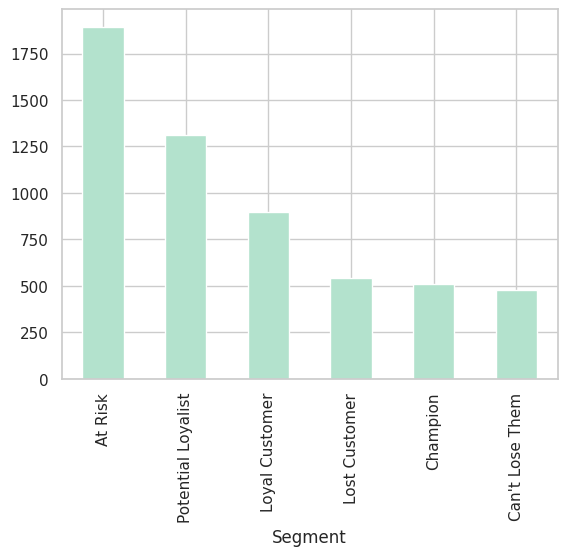

In [89]:
tableRFM['Segment'].value_counts().plot(kind='bar', cmap='Pastel2')

D’après la visualisation du nombre de clients par segment dans le tableau RFM, on observe que :

La majorité des clients appartiennent au segment "At Risk", avec une fréquence d’achat supérieure à 1750.

Ensuite, vient le segment des "Potential Loyalists", qui compte près de 1300 clients avec une fréquence d’achat un peu moins élevée.

Le segment des "Loyal Customers" rassemble entre 750 et 1000 clients, affichant une fréquence d’achat intermédiaire.

Enfin, le segment des "Champions", les clients les plus fidèles et récents, est le plus restreint, avec environ 500 clients.

Cette répartition indique que la majorité des clients risquent de se désengager, ce qui suggère d’adapter les stratégies marketing pour reconquérir ces clients et convertir les "Potential Loyalists" en clients plus fidèles.